In [1]:
import pandas as pd
import numpy as np
import netCDF4 as nc
import xarray as xr
from scipy.spatial import cKDTree
import cmocean.cm as cm
from salishsea_tools import viz_tools
import matplotlib.pyplot as plt

#### Compute and save the climatological file

In [2]:
ds_ca = xr.open_dataset('/ocean/dtaneja/canada_wwtp_sources.nc')
ds_ca

<xarray.Dataset> Size: 520MB
Dimensions:          (y: 898, x: 398, time_counter: 12)
Coordinates:
  * y                (y) int64 7kB 0 1 2 3 4 5 6 ... 891 892 893 894 895 896 897
  * x                (x) int64 3kB 0 1 2 3 4 5 6 ... 391 392 393 394 395 396 397
  * time_counter     (time_counter) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 1MB ...
    nav_lon          (y, x) float32 1MB ...
    area             (y, x) float64 3MB ...
    flux             (time_counter, y, x) float64 34MB ...
    temperature      (time_counter, y, x) float64 34MB ...
    NO3              (time_counter, y, x) float64 34MB ...
    ...               ...
    DON              (time_counter, y, x) float64 34MB ...
    bSi              (time_counter, y, x) float64 34MB ...
    oxygen           (time_counter, y, x) float64 34MB ...
    alkalinity       (time_counter, y, x) float64 34MB ...
    DIC              (time_counter, y, x) float64 34MB ...
    turb             (time_counter, y, x) float64 34MB ...

In [3]:
ds_us = xr.open_dataset("/ocean/atall/MOAD/Obs/PugetSound/WWTP/all_point_source_data_donpon_xygrid_clim.nc")
ds_us = ds_us.assign_coords(time_counter=ds_us.time_counter - 1)  # Adjust month indexing from 1-12 to 0-11
ds_us

<xarray.Dataset> Size: 377MB
Dimensions:       (time_counter: 12, y: 898, x: 398)
Coordinates:
  * time_counter  (time_counter) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Dimensions without coordinates: y, x
Data variables:
    nav_lon       (time_counter, y, x) float32 17MB ...
    nav_lat       (time_counter, y, x) float32 17MB ...
    area          (time_counter, y, x) float64 34MB ...
    flux          (time_counter, y, x) float64 34MB ...
    temperature   (time_counter, y, x) float64 34MB ...
    NO3           (time_counter, y, x) float64 34MB ...
    NH3           (time_counter, y, x) float64 34MB ...
    oxygen        (time_counter, y, x) float64 34MB ...
    alkalinity    (time_counter, y, x) float64 34MB ...
    DIC           (time_counter, y, x) float64 34MB ...
    PON           (time_counter, y, x) float64 34MB ...
    DON           (time_counter, y, x) float64 34MB ...
Attributes:
    acknowledgements:      Based on Ecology data from the University of Washi...
    creator_email:         atall@eoas.ubc.ca
    creator_name:          UBC Salish Sea Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 Wastewater Climatology from wwtp_data_mohamedali_e...
    comment:               Monthly climatology computed from all_point_source...
    notebook:              generate_wwtp_data.ipynb
    summary:               Wastewater climatology, flux, area, and conservati...
    history:               [2025-08-18] Climatology file creation.

In [4]:
input_iona_nc = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wastewater_20231010_iona.nc"
ds_iona = xr.open_dataset(input_iona_nc)
ds_iona

<xarray.Dataset> Size: 520MB
Dimensions:          (y: 898, x: 398, time_counter: 12)
Coordinates:
  * y                (y) int64 7kB 0 1 2 3 4 5 6 ... 891 892 893 894 895 896 897
  * x                (x) int64 3kB 0 1 2 3 4 5 6 ... 391 392 393 394 395 396 397
  * time_counter     (time_counter) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 1MB ...
    nav_lon          (y, x) float32 1MB ...
    area             (y, x) float64 3MB ...
    flux             (time_counter, y, x) float64 34MB ...
    temperature      (time_counter, y, x) float64 34MB ...
    NO3              (time_counter, y, x) float64 34MB ...
    ...               ...
    DON              (time_counter, y, x) float64 34MB ...
    bSi              (time_counter, y, x) float64 34MB ...
    oxygen           (time_counter, y, x) float64 34MB ...
    alkalinity       (time_counter, y, x) float64 34MB ...
    DIC              (time_counter, y, x) float64 34MB ...
    turb             (time_counter, y, x) float64 34MB ...
Attributes:
    acknowledgements:      Based on Metro Data File
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          UBC Salish Sea Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 wastewater_20231010
    comment:               wastewater_20231010 on coordinates_seagrid_SalishS...
    notebook:              Wastewater_File.ipynb
    summary:               Wastewater, flux, area, and conservative temperature
    history:               [2023-10-10] File creation.

In [5]:
ds_all = ds_iona
ds_all

<xarray.Dataset> Size: 520MB
Dimensions:          (y: 898, x: 398, time_counter: 12)
Coordinates:
  * y                (y) int64 7kB 0 1 2 3 4 5 6 ... 891 892 893 894 895 896 897
  * x                (x) int64 3kB 0 1 2 3 4 5 6 ... 391 392 393 394 395 396 397
  * time_counter     (time_counter) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 1MB ...
    nav_lon          (y, x) float32 1MB ...
    area             (y, x) float64 3MB ...
    flux             (time_counter, y, x) float64 34MB ...
    temperature      (time_counter, y, x) float64 34MB ...
    NO3              (time_counter, y, x) float64 34MB ...
    ...               ...
    DON              (time_counter, y, x) float64 34MB ...
    bSi              (time_counter, y, x) float64 34MB ...
    oxygen           (time_counter, y, x) float64 34MB ...
    alkalinity       (time_counter, y, x) float64 34MB ...
    DIC              (time_counter, y, x) float64 34MB ...
    turb             (time_counter, y, x) float64 34MB ...
Attributes:
    acknowledgements:      Based on Metro Data File
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          UBC Salish Sea Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 wastewater_20231010
    comment:               wastewater_20231010 on coordinates_seagrid_SalishS...
    notebook:              Wastewater_File.ipynb
    summary:               Wastewater, flux, area, and conservative temperature
    history:               [2023-10-10] File creation.

In [45]:
var_metadata = {
    "flux": {"units": "mol/m2/s", "long_name": "wastewater flux"},
    "temperature": {"units": "°C", "long_name": "wastewater temperature"},
    "NO3": {"units": "umol/L", "long_name": "wastewater nitrate"},
    "NH3": {"units": "umol/L", "long_name": "wastewater ammonium"},
    "dSi": {"units": "umol/L", "long_name": "wastewater dissolved silicon"},
    "diatoms": {"units": "umol/L", "long_name": "wastewater diatoms"},
    "nanoflagellates": {"units": "umol/L", "long_name": "wastewater nanoflagellates"},
    "Z1": {"units": "umol/L", "long_name": "wastewater Z1 zooplankton"},
    "PON": {"units": "umol/L", "long_name": "particulate organic nitrogen"},
    "DON": {"units": "umol/L", "long_name": "dissolved organic nitrogen"},
    "bSi": {"units": "umol/L", "long_name": "biogenic silicon"},
    "oxygen": {"units": "umol/L", "long_name": "oxygen"},
    "alkalinity": {"units": "umol/L", "long_name": "alkalinity"},
    "DIC": {"units": "umol/L", "long_name": "dissolved inorganic carbon"},
    "turb": {"units": "NTU", "long_name": "turbidity"},
}

vars_to_add = ["flux","DIC","DON","PON","NO3","NH3",
               "oxygen","alkalinity","temperature"]
for v in vars_to_add:
    ds_all[v] = ds_iona[v] + ds_ca[v] + ds_us[v]
    ds_all[v].attrs.update(var_metadata[v])
    
for v in set(ds_all.data_vars) - {"nav_lat","nav_lon","area"}:
    ds_all[v].encoding["_FillValue"] = 0.0
    ds_all[v].encoding["dtype"] = "float64"
for v in ["nav_lat", "nav_lon", "area"]:
    ds_all[v].encoding["_FillValue"] = None
ds_all = ds_all.fillna(0)


In [46]:
ds_alltogether = ds_all

In [47]:
ds_alltogether.attrs.update({
    "acknowledgements": "Based on Metro Data File and Ecology data from the University of Washington for point sources",
    "creator_email": "sallen@eoas.ubc.ca and atall@eoas.ubc.ca",
    "creator_name": "UBC Salish Sea Project Contributors",
    "creator_url": "https://salishsea-meopar-docs.readthedocs.org/",
    "institution": "UBC EOAS",
    "institution_fullname": "Earth, Ocean & Atmospheric Sciences, University of British Columbia",
    "title": "Iona + Wastewater Climatology from wwtp_data_mohamedali_etal_2020 (1999-Jul 2017) + Aurora Leeson (Aug 2017-2020)",
    "comment": "Monthly climatology computed from all_point_source_data_donpon_xygrid.nc and Iona data",
    "notebook": "generate_wwtp_grid_data.ipynb",
    "summary": "Wastewater climatology, flux, area, and conservative temperature",
    "history": f"[{pd.Timestamp.now().strftime('%Y-%m-%d')}] Climatology file creation."
})

In [ ]:
#ds_alltogether.to_netcdf(
#    "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wwtp_20260617.nc",
#    format="NETCDF4",
#    unlimited_dims=["time_counter"])

In [49]:
ds_alltogether

<xarray.Dataset> Size: 520MB
Dimensions:          (y: 898, x: 398, time_counter: 12)
Coordinates:
  * y                (y) int64 7kB 0 1 2 3 4 5 6 ... 891 892 893 894 895 896 897
  * x                (x) int64 3kB 0 1 2 3 4 5 6 ... 391 392 393 394 395 396 397
  * time_counter     (time_counter) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
Data variables: (12/18)
    nav_lat          (y, x) float32 1MB 46.86 46.86 46.86 ... 51.1 51.1 51.1
    nav_lon          (y, x) float32 1MB -123.4 -123.4 -123.4 ... -124.3 -124.3
    area             (y, x) float64 3MB 1.852e+05 1.908e+05 ... 1.755e+05
    flux             (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0
    temperature      (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0
    NO3              (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0
    ...               ...
    DON              (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0
    bSi              (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0
    oxygen           (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0
    alkalinity       (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0
    DIC              (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0
    turb             (time_counter, y, x) float64 34MB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    acknowledgements:      Based on Metro Data File and Ecology data from the...
    creator_email:         sallen@eoas.ubc.ca and atall@eoas.ubc.ca
    creator_name:          UBC Salish Sea Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    title:                 Iona + Wastewater Climatology from wwtp_data_moham...
    comment:               Monthly climatology computed from all_point_source...
    notebook:              generate_wwtp_grid_data.ipynb
    summary:               Wastewater climatology, flux, area, and conservati...
    history:               [2026-06-17] Climatology file creation.

In [50]:
ds_alltogetherFW = ds_alltogether
ds_alltogetherNut = ds_alltogether
vars_to_cancel_FreshW= ["turb","DIC","DON","PON","NO3","NH3",
               "oxygen","alkalinity","bSi","dSi","diatoms",
               "nanoflagellates","Z1"]
for v in vars_to_cancel_FreshW:
    ds_alltogetherFW[v] = ds_alltogetherFW[v] * 0.0
    ds_alltogetherFW[v].attrs.update(var_metadata[v])
vars_to_cancel = ["turb","DIC","DON","PON",#"NO3","NH3",
               "oxygen","alkalinity","bSi","dSi","diatoms",
               "nanoflagellates","Z1"]
for v in vars_to_cancel:
    ds_alltogetherNut[v] = ds_alltogetherNut[v] * 0.0
    ds_alltogetherNut[v].attrs.update(var_metadata[v])

In [ ]:
#ds_alltogetherFW.to_netcdf(
#    "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wwtp_20260617_freshwater.nc",
#    format="NETCDF4",
#    unlimited_dims=["time_counter"])
#ds_alltogetherNut.to_netcdf(
#    "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wwtp_20260617_NO3NH3.nc",
#    format="NETCDF4",
#    unlimited_dims=["time_counter"])

In [26]:
wwtp_all = "/ocean/atall/MOAD/Obs/PugetSound/WWTP/wwtp_20260617.nc"
ds_wwtp = xr.open_dataset(wwtp_all)
ds = ds_wwtp
#ds = ds_iona

In [27]:
flux_nonzero = ds["flux"].max(dim="time_counter") > 0
source_indices = np.argwhere(flux_nonzero.values)

print(f"Found {len(source_indices)} sources")

lon = ds["nav_lon"].values
lat = ds["nav_lat"].values

Found 138 sources


/home/atall/conda_envs/analysis-abdoul-314/lib/python3.14/site-packages/IPython/core/events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


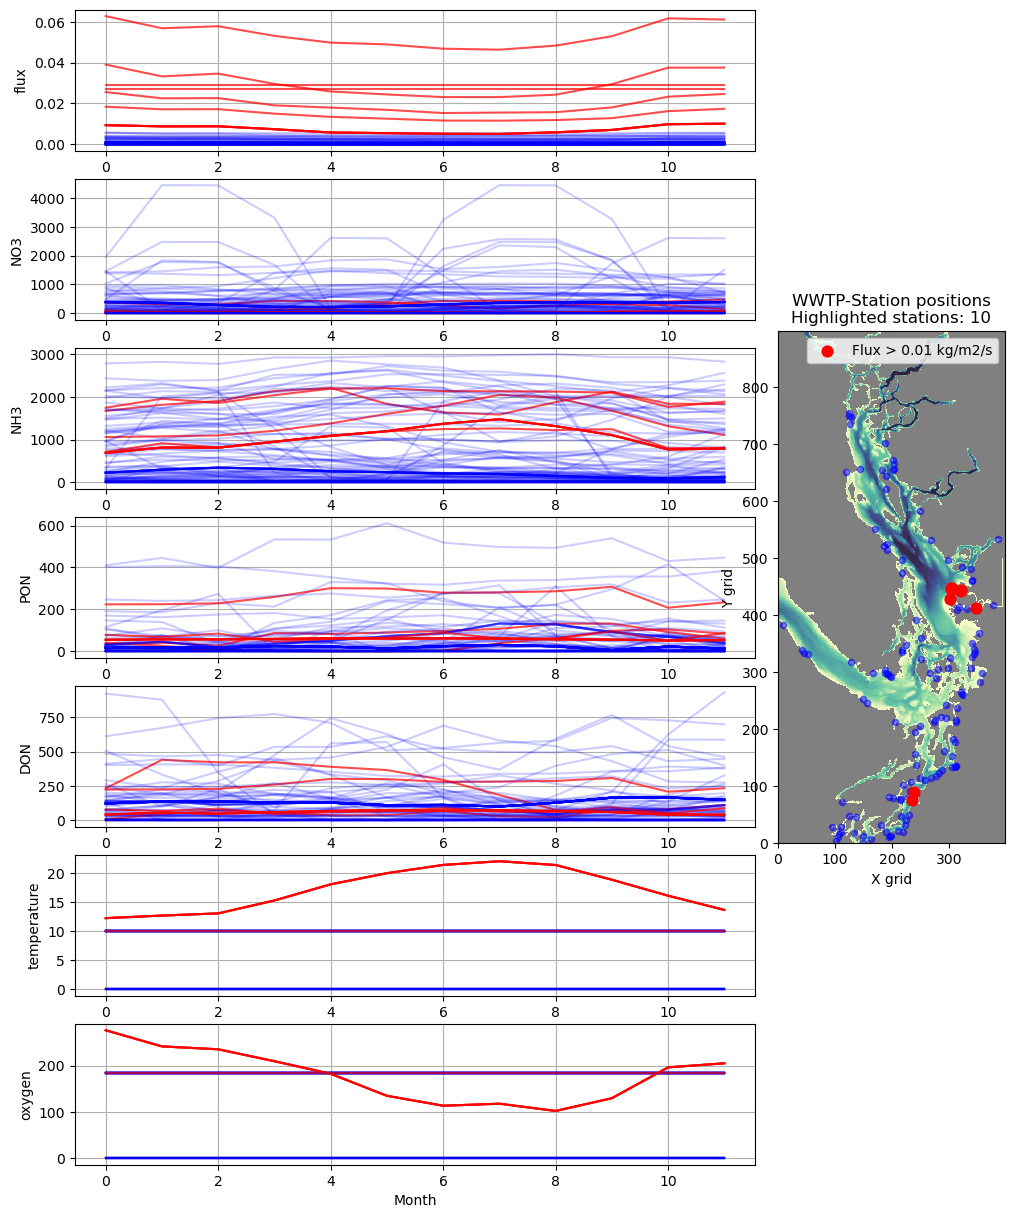

In [28]:
bathy = nc.Dataset('/ocean/atall/MOAD/grid/bathymetry_202108.nc')
import matplotlib.gridspec as gridspec

time = ds["time_counter"].values
threshold = 0.01

# Colormap for bathymetry
mycmap = cm.deep
mycmap.set_bad('grey')

vars_to_plot = ["flux", "NO3", "NH3", "PON", "DON", "temperature","oxygen"]
n_vars = len(vars_to_plot)

# Create figure with GridSpec
fig = plt.figure(figsize=(12, 15))
gs = gridspec.GridSpec(n_vars, 2, width_ratios=[3, 1], wspace=0.05)

axes = []

# Left: time series axes (n_vars rows)
for i in range(n_vars):
    ax = fig.add_subplot(gs[i,0])
    axes.append(ax)

highlighted_stations = []

# Time series plots (left)
for idx, (iy, ix) in enumerate(source_indices):
    for i, var in enumerate(vars_to_plot):
        data = ds[var][:, iy, ix].values
        
        if ds["flux"][:, iy, ix].max() > threshold:
            axes[i].plot(time, data, color="red", alpha=0.7)
            highlighted_stations.append((iy, ix))
        else:
            axes[i].plot(time, data, color="blue", alpha=0.2)
        
        axes[i].set_ylabel(var)
        axes[i].grid(True)

axes[-1].set_xlabel("Month")

highlighted_stations = list(dict.fromkeys(highlighted_stations)) # Remove duplicates

# Right: map axis 
ax_map = fig.add_subplot(gs[:,1])  # span all rows

bathy_data = bathy.variables['Bathymetry'][:]
ax_map.pcolormesh(bathy_data, cmap=mycmap, vmin=0, vmax=450)

all_y, all_x = zip(*source_indices)
ax_map.scatter(all_x, all_y, color='blue', alpha=0.5, s=20)

highlight_y, highlight_x = zip(*highlighted_stations)
ax_map.scatter(highlight_x, highlight_y, color='red', s=60, label='Flux > 0.01 kg/m2/s') # Highlight stations

ax_map.set_title(f"WWTP-Station positions\nHighlighted stations: {len(highlighted_stations)}")
ax_map.set_xlabel("X grid")
ax_map.set_ylabel("Y grid")
#ax_map.set_ylim(0, 500)
ax_map.legend()
ax_map.set_aspect('equal')

#plt.tight_layout()
#plt.show()

No nutrients, oxygen, temperature, ... from the Canadian WWTP file except iona. Vars.values = 0

There a few WWTP in the Canada side from the US file

Next: Values to be found, at least the Nanaimo one! For those not available add a constant values for temperature and oxygen